<a href="https://colab.research.google.com/github/Ayushman2005-cmyk/AML_EXPERIMENTS/blob/main/AML_LAB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [ ]:
def train_and_evaluate(X, y, title):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    m = LinearRegression().fit(X_tr, y_tr)
    p = m.predict(X_te)
    mse, mae, r2 = metrics.mean_squared_error(y_te, p), metrics.mean_absolute_error(y_te, p), metrics.r2_score(y_te, p)
    rmse = np.sqrt(mse)
    eq = f"y = {m.intercept_:.4f}" + "".join([f" + {c:.4f} * {col}" for c, col in zip(m.coef_, X.columns)])
    print(f"\n--- {title} ---\nEq: {eq}\nMSE: {mse:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")
    return m, X_te, y_te, p, [mae, mse, rmse, r2]

In [ ]:
def plot_chart(ctype, x, y, title, xl, yl, p=None):
    plt.figure()
    if ctype == 'scatter_line':
        plt.scatter(x, y, color='#06b6d4', label='Actual')
        plt.plot(x, p, color='#7c3aed', lw=2, label='Regression')
    elif ctype == 'actual_vs_pred':
        plt.scatter(x, y, color='#f43f5e', label='Predictions')
        plt.plot([x.min(), x.max()], [x.min(), x.max()], color='#10b981', linestyle='--', label='Ideal Fit')
    elif ctype == 'metrics_bar':
        bars = plt.barh(["MAE", "MSE", "RMSE", "R2"], x, color=['#7c3aed', '#06b6d4', '#10b981', '#f59e0b'])
        for b in bars: plt.annotate(f"{b.get_width():.4f}", xy=(b.get_width(), b.get_y() + b.get_height()/2), va="center")
    if ctype != 'metrics_bar': plt.legend()
    plt.title(title); plt.xlabel(xl); plt.ylabel(yl); plt.grid(True); plt.show()

Shape: (25, 7)

Nulls:
Hours        0
Practice     0
TeamWork     0
MidTerm      0
FinalExam    0
Scores       0
Grade        0
dtype: int64

Stats:
           Hours   Practice   TeamWork    MidTerm  FinalExam     Scores
count  25.000000  25.000000  25.000000  25.000000  25.000000  25.000000
mean    5.012000   2.760000   1.812000   4.920000   5.348000  51.480000
std     2.525094   1.722885   1.697871   2.325941   2.528689  25.286887
min     1.100000   0.200000   0.000000   2.000000   1.900000  17.000000
25%     2.700000   1.500000   0.500000   3.000000   3.200000  30.000000
50%     4.800000   2.500000   1.200000   4.000000   4.900000  47.000000
75%     7.400000   3.700000   3.000000   7.000000   7.700000  75.000000
max     9.200000   6.200000   6.000000   9.000000   9.700000  95.000000


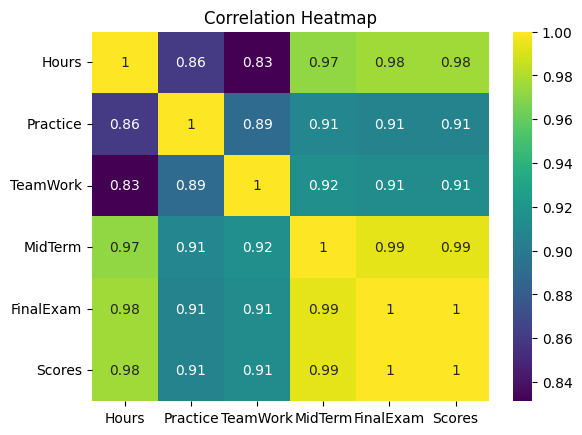

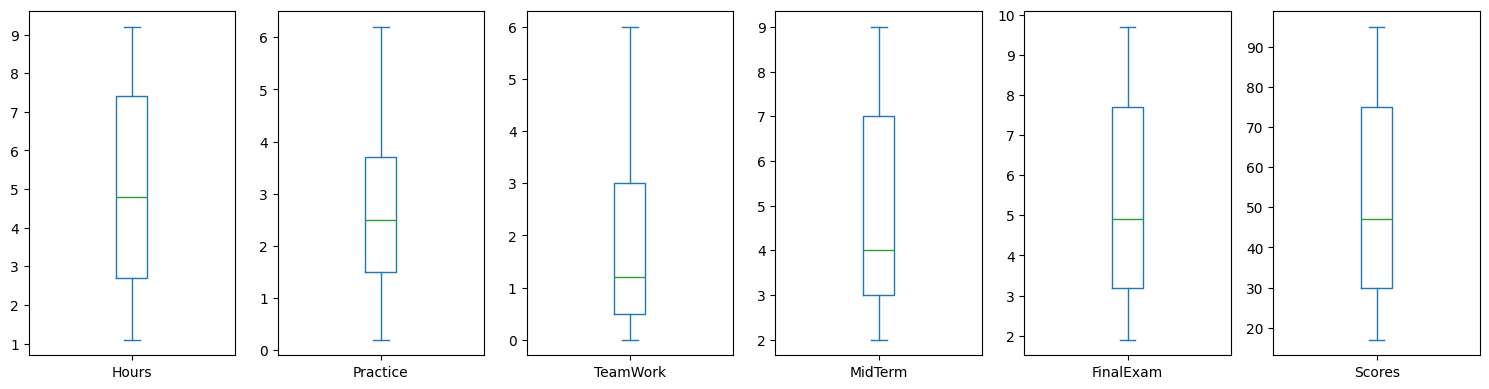


Top correlated feature with Scores is: 'FinalExam'

--- Simple Linear Regression ---
Eq: y = -2.0000 + 10.0000 * FinalExam
MSE: 0.0000 | MAE: 0.0000 | RMSE: 0.0000 | R²: 1.0000


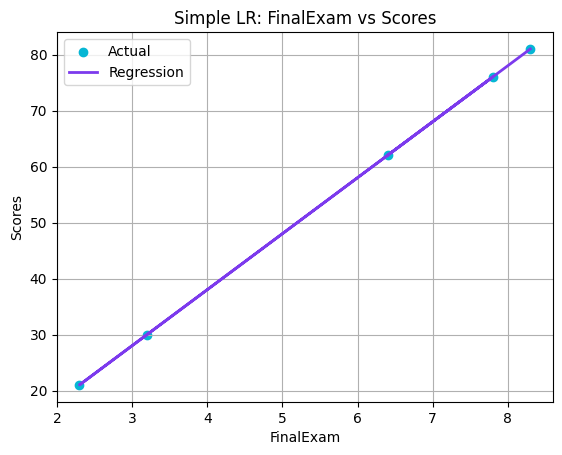

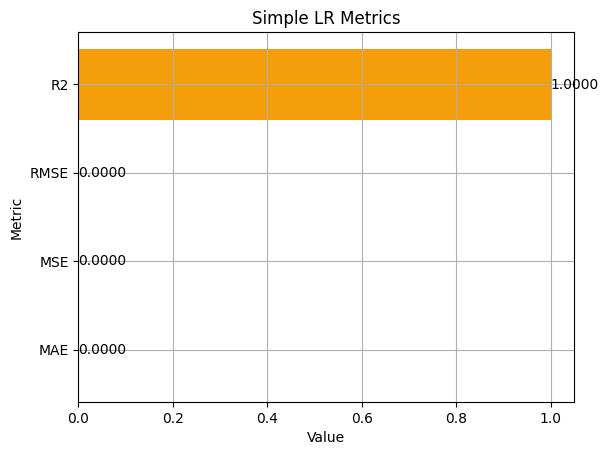


--- Multiple Linear Regression ---
Eq: y = -2.0000 + 0.0000 * MidTerm + 10.0000 * FinalExam
MSE: 0.0000 | MAE: 0.0000 | RMSE: 0.0000 | R²: 1.0000


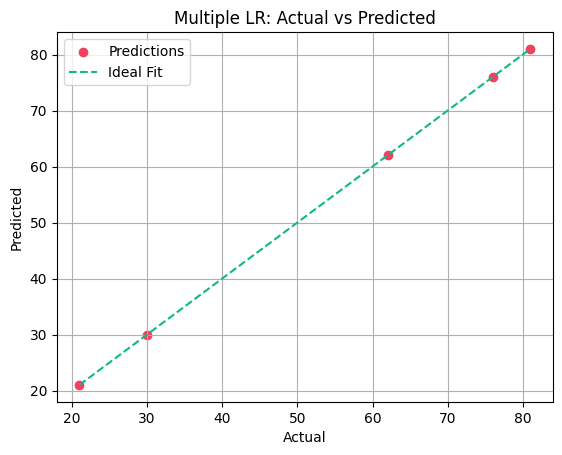

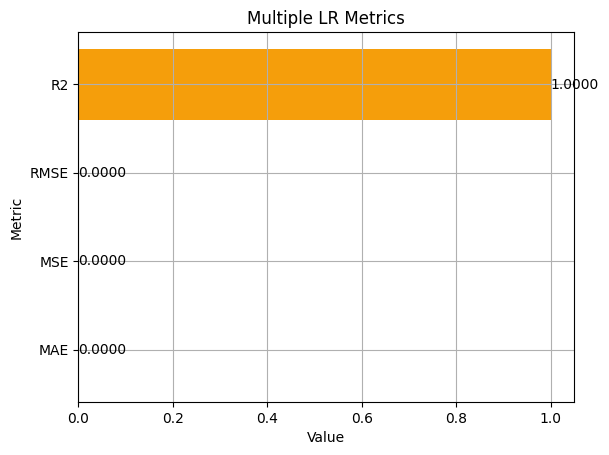


--- Enter Marks to Predict Scores ---
Enter MidTerm marks: 10
Enter FinalExam marks: 10

The predicted Score is: 98.00


In [ ]:
df = pd.read_csv('Student_Grades.csv')
print(f"Shape: {df.shape}\n\nNulls:\n{df.isnull().sum()}\n\nStats:\n{df.describe()}")
sns.heatmap(df.drop(columns=['Grade']).corr(), annot=True, cmap='viridis').set_title('Correlation Heatmap'); plt.show()
df.plot(kind='box', subplots=True, figsize=(15, 4)); plt.tight_layout(); plt.show()
X, y = df[['MidTerm', 'FinalExam']], df['Scores']
best = X.corrwith(y).abs().idxmax()
print(f"\nTop correlated feature with Scores is: '{best}'")
_, X_te_s, y_te_s, p_s, m_s = train_and_evaluate(df[[best]], y, 'Simple Linear Regression')
plot_chart('scatter_line', X_te_s, y_te_s, f'Simple LR: {best} vs Scores', best, 'Scores', p_s)
plot_chart('metrics_bar', m_s, None, 'Simple LR Metrics', 'Value', 'Metric')
m_m, _, y_te_m, p_m, m_m_mets = train_and_evaluate(X, y, 'Multiple Linear Regression')
plot_chart('actual_vs_pred', y_te_m, p_m, 'Multiple LR: Actual vs Predicted', 'Actual', 'Predicted')
plot_chart('metrics_bar', m_m_mets, None, 'Multiple LR Metrics', 'Value', 'Metric')
print("\n--- Enter Marks to Predict Scores ---")
u_inp = pd.DataFrame([[float(input(f"Enter {col} marks: ")) for col in X.columns]], columns=X.columns)
print(f"\nThe predicted Score is: {m_m.predict(u_inp)[0]:.2f}")